In [1]:
import stim
import sys
import pymatching
import numpy as np
sys.path.append('..')

In [75]:
circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=1,
    distance=3,
    before_round_data_depolarization=0.03,
    before_measure_flip_probability=0.02)

In [76]:
print(circuit)

QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 1) 3
QUBIT_COORDS(5, 1) 5
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(2, 2) 9
QUBIT_COORDS(3, 3) 10
QUBIT_COORDS(4, 2) 11
QUBIT_COORDS(5, 3) 12
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(0, 4) 14
QUBIT_COORDS(1, 5) 15
QUBIT_COORDS(2, 4) 16
QUBIT_COORDS(3, 5) 17
QUBIT_COORDS(4, 4) 18
QUBIT_COORDS(5, 5) 19
QUBIT_COORDS(4, 6) 25
R 1 3 5 8 10 12 15 17 19 2 9 11 13 14 16 18 25
TICK
DEPOLARIZE1(0.03) 1 3 5 8 10 12 15 17 19
H 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 2 1 16 15 11 10 8 14 3 9 12 18
TICK
CX 16 10 11 5 25 19 8 9 17 18 12 13
TICK
CX 16 8 11 3 25 17 1 9 10 18 5 13
TICK
H 2 11 16 25
TICK
X_ERROR(0.02) 2 9 11 13 14 16 18 25
MR 2 9 11 13 14 16 18 25
DETECTOR(0, 4, 0) rec[-4]
DETECTOR(2, 2, 0) rec[-7]
DETECTOR(4, 4, 0) rec[-2]
DETECTOR(6, 2, 0) rec[-5]
X_ERROR(0.02) 1 3 5 8 10 12 15 17 19
M 1 3 5 8 10 12 15 17 19
DETECTOR(0, 4, 1) rec[-3] rec[-6] rec[-13]
DETECTOR(2, 2, 1) rec[-5] rec[-6] rec[-8] rec[-9] rec[-16]
DETECTOR(4, 4,

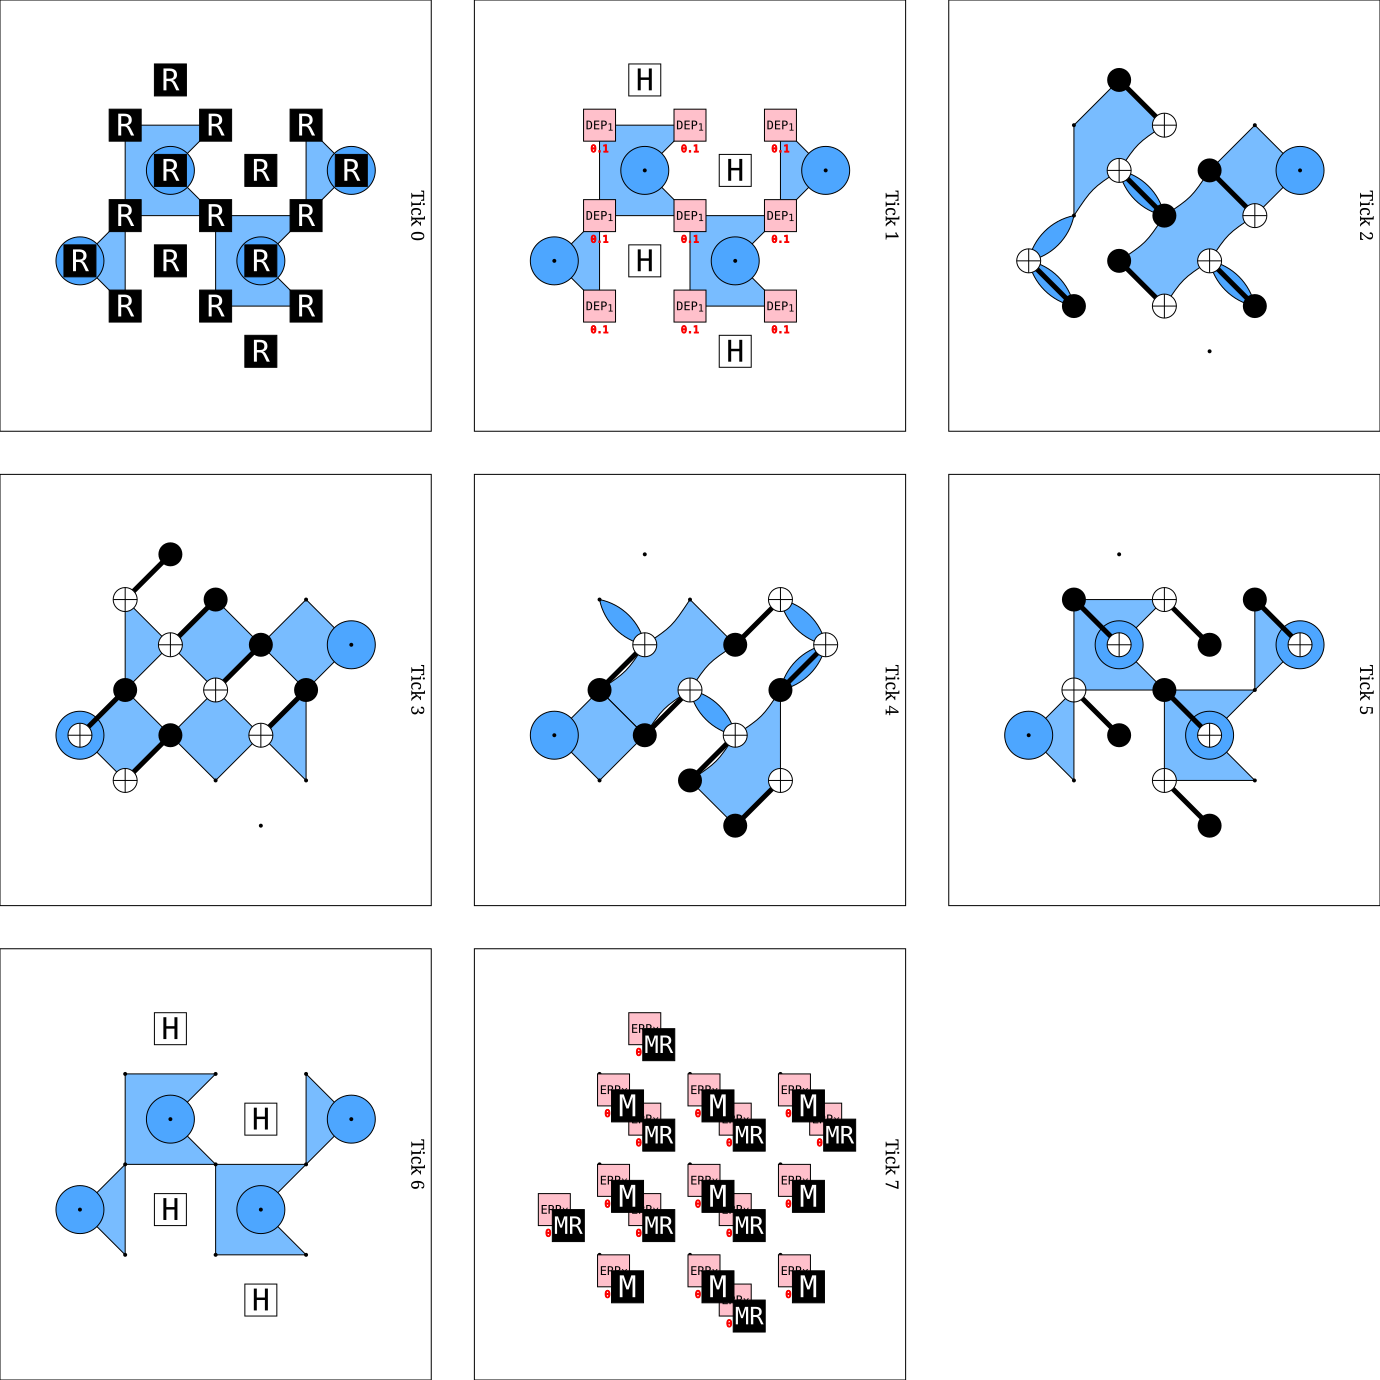

In [ ]:
circuit.diagram('detslice-with-ops-svg')

In [143]:
sampler = stim.CompiledDetectorSampler = circuit.compile_detector_sampler()
sampler.sample_write(
    shots=1000,
    filepath='symptoms.txt',
    format='01',
    obs_out_filepath='values_to_predict.txt',
    obs_out_format='01',
)

In [ ]:
det_events, obs_flips = sampler.sample(10, separate_observables=True)
print(list(map(lambda x: list(map(int, x)), det_events)))

print([int(b[0]) for b in obs_flips])

[[0, 0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 0, 0, 1, 0], [0, 0, 0, 0, 1, 0, 0, 0], [0, 1, 1, 0, 0, 1, 1, 1], [1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 1], [0, 0, 0, 0, 1, 1, 0, 0]]
[0, 0, 0, 0, 0, 1, 0, 0, 0, 1]


In [2]:
def load_detobs_data(data_path, labels_path, zip_to_tuple = False):
    """
    Creates a list of tuples, where each tuple contains a line from
    data_path and a corresponding line from labels_path.
    When data is stored by .sample_write() in STIM, the detector data
    are stored as a string and this function will automatically convert
    them to their proper list list int form for use with the dataloader
    """
    with open(data_path, 'r') as f1:
        data = f1.readlines()
    
    with open(labels_path, 'r') as f2:
        labels = f2.readlines()

    # Remove newline characters from the end of each line
    data = [list(map(int, line.strip())) for line in data]
    labels = [int(line.strip()) for line in labels]
    
    if zip_to_tuple:
    # Use zip to combine lines into tuples
        tuple_array = list(zip(data, labels))
        return tuple_array
    else:
        return data, labels
    
def detobs_sampler(circuit: stim.Circuit, shots: int, as_boolean = False):
    """
    Samples the specified number of shots from the given circuit. Converts the boolean detector events -> list of list of ints
    and observable flips -> list of 
    to list of list of  Returns the detection events
    and observable flips as arrays of bi
    """
    sampler = circuit.compile_detector_sampler()
    det_events, obs_flips = sampler.sample(shots, separate_observables=True)
    # return det_events, obs_flips
    # det_list = np.ndarray(map(lambda x: list(map(int, x)), det_events))
    # obs_list = [int(b[0]) for b in obs_flips]
    # det_list = np.ndarray(map(lambda x: list(map(int, x)), det_events))
    # obs_list = 
    return det_events.astype(int), obs_flips.astype(int)

In [6]:
def count_logical_errors(circuit, detection_events, observable_flips, num_shots: int) -> int:
    # Sample the circuit.
    # sampler = circuit.compile_detector_sampler()
    # detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

    # Configure a decoder using the circuit.
    detector_error_model = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

    # Run the decoder.
    predictions = matcher.decode_batch(detection_events)

    # Count the mistakes.
    num_errors = 0
    for shot in range(num_shots):
        actual_for_shot = observable_flips[shot]
        predicted_for_shot = predictions[shot]
        if not np.array_equal(actual_for_shot, predicted_for_shot):
            num_errors += 1
    return num_errors

def eval_pymatching(circuit, detection_events, observable_flips, num_shots):
    num_logical_errors = count_logical_errors(circuit=circuit, detection_events=detection_events, observable_flips=observable_flips, num_shots=num_shots)
    num_correct_preds = num_shots - num_logical_errors
    print(f"Correctly predicted {num_correct_preds} out of {num_shots}")
    print(f"Evaluation Accuracy: {num_correct_preds/num_shots:.4f}")

In [103]:
num_shots = 1000
circuit = stim.Circuit.generated("surface_code:rotated_memory_z", 
                                 rounds=1, 
                                 distance=3, 
                                 before_round_data_depolarization=0.03,
                                 before_measure_flip_probability=0.02)
detection_events, observable_flips = detobs_sampler(circuit, num_shots)


In [105]:
circuit

stim.Circuit('''
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(5, 1) 5
    QUBIT_COORDS(1, 3) 8
    QUBIT_COORDS(2, 2) 9
    QUBIT_COORDS(3, 3) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(5, 3) 12
    QUBIT_COORDS(6, 2) 13
    QUBIT_COORDS(0, 4) 14
    QUBIT_COORDS(1, 5) 15
    QUBIT_COORDS(2, 4) 16
    QUBIT_COORDS(3, 5) 17
    QUBIT_COORDS(4, 4) 18
    QUBIT_COORDS(5, 5) 19
    QUBIT_COORDS(4, 6) 25
    R 1 3 5 8 10 12 15 17 19 2 9 11 13 14 16 18 25
    TICK
    DEPOLARIZE1(0.03) 1 3 5 8 10 12 15 17 19
    H 2 11 16 25
    TICK
    CX 2 3 16 17 11 12 15 14 10 9 19 18
    TICK
    CX 2 1 16 15 11 10 8 14 3 9 12 18
    TICK
    CX 16 10 11 5 25 19 8 9 17 18 12 13
    TICK
    CX 16 8 11 3 25 17 1 9 10 18 5 13
    TICK
    H 2 11 16 25
    TICK
    X_ERROR(0.02) 2 9 11 13 14 16 18 25
    MR 2 9 11 13 14 16 18 25
    DETECTOR(0, 4, 0) rec[-4]
    DETECTOR(2, 2, 0) rec[-7]
    DETECTOR(4, 4, 0) rec[-2]
    DETECTOR(6, 2, 0) rec[-5]
    X_ERR

In [108]:
detslice_diagram = circuit.diagram('detslice-with-ops-svg')
timeline_diagram = circuit.diagram('timeline-svg')
with open('detslice-diagram-d3.svg', 'w') as f:
    print(detslice_diagram, file=f)
with open('timeline-diagram-d3.svg', 'w') as f:
    print(timeline_diagram, file=f)

In [117]:
circuit.diagram('matchgraph-3d')

{"accessors":[{"bufferView":0,"byteOffset":0,"componentType":5126,"count":9,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":1,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0,0.400000005960464],"min":[-0.400000005960464,0,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":2,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0.400000005960464,0],"min":[-0.400000005960464,-0.400000005960464,0],"name":"circle_loop","type":"VEC3"},{"bufferView":3,"byteOffset":0,"componentType":5126,"count":9,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":4,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0,0.400000005960464],"min":[-0.400000005960464,0,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":5,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0.400000005960464,0],"min":[-0.400000005960464,-0.400000005960464,0],"name":"circle_loop","type":"VEC3"},{"bufferView":6,"byteOffset":0,"componentType":5126,"count":28,"max":[18.6666679382324,18.6666679382324,6.33333349227905],"min":[-9.3704252243042,6,-3.33333349227905],"name":"buf_scattered_lines","type":"VEC3"},{"bufferView":7,"byteOffset":0,"componentType":5126,"count":8,"max":[27.3704261779785,6,6.33333349227905],"min":[-0.666666984558105,-0.666666984558105,-3.33333349227905],"name":"buf_red_scattered_lines","type":"VEC3"}],"asset":{"version":"2.0"},"bufferViews":[{"buffer":0,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":1,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":2,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":3,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":4,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":5,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":6,"byteLength":336,"byteOffset":0,"name":"buf_scattered_lines","target":34962},{"buffer":7,"byteLength":96,"byteOffset":0,"name":"buf_red_scattered_lines","target":34962}],"buffers":[{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAM3MzD4AAAAAAAAAAMPQkD7D0JA+AAAAAPIwlrLNzMw+AAAAAMPQkL7D0JA+AAAAAM3MzL7yMBazAAAAAMHQkL7E0JC+AAAAAPLkozHNzMy+AAAAAMbQkD6/0JC+AAAAAM3MzD4AAAAA"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAAAAAADNzMw+w9CQPgAAAADD0JA+zczMPgAAAADyMJayw9CQPgAAAADD0JC+8jAWswAAAADNzMy+xNCQvgAAAADB0JC+zczMvgAAAADy5KMxv9CQvgAAAADG0JA+AAAAAAAAAADNzMw+"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,zczMPgAAAAAAAAAAw9CQPsPQkD4AAAAA8jCWss3MzD4AAAAAw9CQvsPQkD4AAAAAzczMvvIwFrMAAAAAwdCQvsTQkL4AAAAA8uSjMc3MzL4AAAAAxtCQPr/QkL4AAAAAzczMPgAAAAAAAAAA"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAM3MzD4AAAAAAAAAAMPQkD7D0JA+AAAAAPIwlrLNzMw+AAAAAMPQkL7D0JA+AAAAAM3MzL7yMBazAAAAAMHQkL7E0JC+AAAAAPLkozHNzMy+AAAAAMbQkD6/0JC+AAAAAM3MzD4AAAAA"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAAAAAADNzMw+w9CQPgAAAADD0JA+zczMPgAAAADyMJayw9CQPgAAAADD0JC+8jAWswAAAADNzMy+xNCQvgAAAADB0JC+zczMvgAAAADy5KMxv9CQvgAAAADG0JA+AAAAAAAAAADNzMw+"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,zczMPgAAAAAAAAAAw9CQPsPQkD4AAAAA8jCWss3MzD4AAAAAw9CQvsPQkD4AAAAAzczMvvIwFrMAAAAAwdCQvsTQkL4AAAAA8uSjMc3MzL4AAAAAxtCQPr/QkL4AAAAAzczMPgAAAAAAAAAA"},{"byteLength":336,"name":"buf_scattered_lines","uri":"data:application/octet-stream;base64,AAAAAAAAQEEAAAAAQ+0VwcH5cUEE58e/AAAAAAAAQEEAAAAAAADAQAAAwEAAAAAAAAAAAAAAQEEAAAAAAAAAAAAAQEEAAEBAAADAQAAAwEAAAAAAAABAQQAAQEEAAAAAAADAQAAAwEAAAAAAAADAQAAAwEAAAEBAAABAQQAAQEEAAAAAVlWVQVZVlUFWVVXAAABAQQAAQEEAAAAAAACQQ

In [79]:
num_logical_errors = count_logical_errors(circuit, detection_events, observable_flips, num_shots)
eval_pymatching(circuit, detection_events, observable_flips, num_shots)


Correctly predicted 887 out of 1000
Evaluation Accuracy: 0.8870


In [12]:
import neat

# XOR test cases: input -> expected output
xor_inputs = [(0.0, 0.0), (0.0, 1.0), (1.0, 0.0), (1.0, 1.0)]
xor_outputs = [(0.0,),    (1.0,),    (1.0,),    (0.0,)]

def eval_genomes(genomes, config):
    """Fitness function: evaluates how well each genome solves XOR."""
    for genome_id, genome in genomes:
        # Create a neural network from this genome
        net = neat.nn.FeedForwardNetwork.create(genome, config)

        # Start with perfect fitness, subtract error
        genome.fitness = 4.0

        # Test on all 4 XOR cases
        for xi, xo in zip(xor_inputs, xor_outputs):
            output = net.activate(xi)
            genome.fitness -= (output[0] - xo[0]) ** 2

# Load configuration
config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                     neat.DefaultSpeciesSet, neat.DefaultStagnation,
                     'config_memory')

# Create population
p = neat.Population(config)
p.add_reporter(neat.StdOutReporter(True))

# Run evolution for up to 300 generations
winner = p.run(eval_genomes, 300)

# Test the winner
print('\nBest genome:\n{!s}'.format(winner))


 ****** Running generation 0 ****** 

Population's average fitness: 2.27446 stdev: 0.33260
Best fitness: 2.99400 - size: (1, 2) - species 1 - id 147
Average adjusted fitness: 0.509
Mean genetic distance 1.131, standard deviation 0.425
Population of 150 members in 1 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
     1    0   150      3.0    0.509     0
Total extinctions: 0
Generation time: 0.005 sec

 ****** Running generation 1 ****** 

Population's average fitness: 2.27709 stdev: 0.33785
Best fitness: 2.99400 - size: (1, 2) - species 1 - id 147
Average adjusted fitness: 0.510
Mean genetic distance 1.213, standard deviation 0.446
Population of 150 members in 1 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
     1    1   150      3.0    0.510     1
Total extinctions: 0
Generation time: 0.005 sec (0.005 average)

 ****** Running generation 2 ****** 

Population's average fitness: 2.30537 stdev: 

In [216]:
load_detobs_data('symptoms.txt','values_to_predict.txt')

([[0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 1, 1, 1, 0, 0, 1],
  [0, 0, 1, 0, 0, 0, 1, 1],
  [0, 0, 0, 0, 0, 1, 0, 0],
  [1, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 0, 1, 0, 0, 0],
  [0, 1, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 0, 1, 1, 0, 0],
  [1, 1, 0, 0, 0, 0, 0, 0],
  [0, 0, 1, 0, 0, 0, 0, 0],
  [0, 1, 0, 0, 0, 0, 1, 1],
  [0, 1, 1, 0, 0, 1, 0, 0],
  [1, 0, 0, 0, 0, 0, 0, 0],
  [1, 0, 0, 1, 1, 0, 1, 1],
  [0, 0, 0, 1, 0, 0, 0, 1],
  [0, 0, 1, 1, 0, 1, 1, 0],
  [0, 0, 0, 0, 1, 0, 1, 0],
  [1, 0, 0, 1, 1, 1, 0, 0],
  [1, 0, 0, 0, 0, 0, 0, 0],
  [0, 1, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0, 0, 0, 0],
  [0, 1, 0, 0, 0, 1, 1, 1],
  [0, 0, 0, 0, 1, 0, 1, 0],
  [1, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 1, 1, 0, 1, 0, 0],
  [0, 1, 0, 0, 0, 0, 0, 0],
  [0, 0, 1, 0, 0, 1, 1, 0],
  [0, 0, 0, 1, 0, 0, 0, 1],
  [0, 1, 1, 0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 1, 1, 1, 0, 1],
  [0, 0, 1, 0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0, 0, 1, 0],
  [0, 0, 0, 0, 0, 1, 0, 0],
  [0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 1, 0, 0, 1,

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

class BinaryStringDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # input_tensor = torch.tensor([float(char) for char in self.data[idx]], dtype=torch.float32)
        input_tensor = torch.tensor(self.data[idx], dtype=torch.float32)
        label_tensor = torch.tensor(self.labels[idx][0] if isinstance(self.labels[idx], np.ndarray) else self.labels[idx], dtype=torch.float32) # For BCEWithLogitsLoss, labels should be float
        return input_tensor, label_tensor
    
def train_test_split(dataset : Dataset, ratio = [0.8, 0.2], generator = None):
        return random_split(dataset, 
                            ratio, 
                            generator if generator else torch.Generator().manual_seed(42))

class BinaryClassifier(nn.Module):
    def __init__(self, input_size, hidden_size):
            super(BinaryClassifier, self).__init__()
            self.fc1 = nn.Linear(input_size, hidden_size)
            self.relu = nn.ReLU()
            self.fc2 = nn.Linear(hidden_size, 1)
            self.sigmoid = nn.Sigmoid()

    def forward(self, x):
            out = self.fc1(x)
            out = self.relu(out)
            out = self.fc2(out)
            out = self.sigmoid(out)
            return out

In [67]:
def train(encoded_data : BinaryStringDataset, epochs=100, hidden_size=5, lr=0.01, batch_size=2, verbose=True):
    input_length = len(encoded_data[0][0])
    input_size = input_length
    model = BinaryClassifier(input_size, hidden_size)

    # 3. Training
    criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Create a DataLoader from the provided dataset/list with batch_size=2
    dataloader = DataLoader(encoded_data, batch_size=batch_size, shuffle=True)

    num_epochs = epochs
    for epoch in range(num_epochs):
        for inputs, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)  # Squeeze to match dimensions
            loss.backward()
            optimizer.step()

        if (epoch + 1) % 10 == 0 and verbose:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
    return model

In [64]:
def eval_model(dataset, model, batch_size=2, verbose = True):
    model.eval()

    dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=False)
    correct_predictions = 0
    total_samples = 0
    loss_function = nn.BCEWithLogitsLoss()
    total_loss = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            # Forward pass
            outputs = model(inputs)

            # Calculate loss
            loss = loss_function(outputs.squeeze(), labels)
            total_loss += loss.item()

            # Convert logits to binary predictions
            predicted_classes = (torch.sigmoid(outputs) > 0.5).float()
            # print("Predict:",predicted_classes)
            # print("Correct:",labels)

            for prediction, actual in zip(predicted_classes, labels):
                # print(f"Predict:{prediction}")
                # print(f"Correct:{actual}")
                correct_predictions += prediction == actual
                # print(f"Guessed Correctly?:{prediction == actual}\n")
                # print(correct_predictions)

            # Calculate accuracy
            # correct_predictions += (predicted_classes == labels).sum().item()
            # print("# correct:",(predicted_classes == labels).sum().item())
            total_samples += labels.size(0)

    num_errors = total_samples - correct_predictions
    accuracy = int(correct_predictions) / total_samples
    average_loss = total_loss / total_samples
    if verbose:
        print(f"Correctly predicted {int(correct_predictions)} out of {total_samples}")
        print(f"Evaluation Accuracy: {accuracy}")
        print(f"Average Evaluation Loss: {average_loss}")
    return num_errors

In [47]:
def nn_num_logical_errors(model, dataset):
    return eval_model(model, dataset, verbose=False)

In [49]:
data, labels = load_detobs_data('symptoms.txt','values_to_predict.txt')
# data, labels = 

In [96]:
# dataset = BinaryStringDataset(data, labels)
dataset = BinaryStringDataset(detection_events, observable_flips)
train_set, test_set = train_test_split(dataset, [.85, .15])


In [82]:
model = train(dataset)

Epoch [10/100], Loss: 0.0322
Epoch [20/100], Loss: 0.3710
Epoch [30/100], Loss: 0.5843
Epoch [40/100], Loss: 0.0000
Epoch [50/100], Loss: 0.0002
Epoch [60/100], Loss: 0.7550
Epoch [70/100], Loss: 0.2126
Epoch [80/100], Loss: 0.3893
Epoch [90/100], Loss: 0.0000
Epoch [100/100], Loss: 0.0000


In [86]:
eval_model(test_set, model)

Correctly predicted 117 out of 150
Evaluation Accuracy: 0.78
Average Evaluation Loss: 0.2767284921805064


tensor([33])

In [141]:
# data = [
#     '101',
#     '000',
#     '110',
#     '010',
#     '111',
#     '001'
# ]
# labels = [
#     1,
#     0,
#     1,
#     0,
#     1,
#     0
# ]

data = [
    '000',
    '001',
    '010',
    '011',
    '100',
    '101',
    '110',
    '111'
]
labels = [
    0,
    1,
    1,
    0,
    1,
    0,
    0,
    1
]
dataset = BinaryStringDataset(data, labels)
train_set, test_set = train_test_split(dataset, [.75, .25])
print(train_set[0])
print(test_set[0])
# dataloader = DataLoader(dataset, batch_size=3)
model = train(dataset)

(tensor([1., 1., 0.]), tensor(0.))
(tensor([1., 0., 0.]), tensor(1.))
Epoch [10/100], Loss: 0.7130
Epoch [20/100], Loss: 0.6807
Epoch [30/100], Loss: 0.6818
Epoch [40/100], Loss: 0.5477
Epoch [50/100], Loss: 0.7053
Epoch [60/100], Loss: 0.7308
Epoch [70/100], Loss: 0.7167
Epoch [80/100], Loss: 0.7698
Epoch [90/100], Loss: 0.6888
Epoch [100/100], Loss: 0.3094


In [98]:
print(detection_events)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 1 0 ... 0 1 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [99]:
import neat

# XOR test cases: input -> expected output
# xor_inputs = [(0.0, 0.0), (0.0, 1.0), (1.0, 0.0), (1.0, 1.0)]
# xor_outputs = [(0.0,),    (1.0,),    (1.0,),    (0.0,)]
inputs = detection_events
outputs = observable_flips

def eval_genomes(genomes, config):
    """Fitness function: evaluates how well each genome solves XOR."""
    for genome_id, genome in genomes:
        # Create a neural network from this genome
        net = neat.nn.FeedForwardNetwork.create(genome, config)

        # Start with perfect fitness, subtract error
        genome.fitness = 4.0

        # Test on all 4 XOR cases
        for xi, xo in zip(inputs, outputs):
            output = net.activate(xi)
            genome.fitness -= (output[0] - xo[0]) ** 2

# Load configuration
config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                     neat.DefaultSpeciesSet, neat.DefaultStagnation,
                     'config_memory')

# Create population
p = neat.Population(config)
p.add_reporter(neat.StdOutReporter(True))

# Run evolution for up to 300 generations
winner = p.run(eval_genomes, 300)

# Test the winner
print('\nBest genome:\n{!s}'.format(winner))


 ****** Running generation 0 ****** 

Population's average fitness: -442.00237 stdev: 199.59617
Best fitness: -182.18739 - size: (1, 24) - species 1 - id 93
Average adjusted fitness: 0.581
Mean genetic distance 0.951, standard deviation 0.288
Population of 150 members in 1 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
     1    0   150   -182.2    0.581     0
Total extinctions: 0
Generation time: 4.110 sec

 ****** Running generation 1 ****** 

Population's average fitness: -242.77356 stdev: 78.38593
Best fitness: -159.91098 - size: (1, 23) - species 1 - id 279
Average adjusted fitness: 0.821
Mean genetic distance 1.207, standard deviation 0.339
Population of 150 members in 1 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
     1    1   150   -159.9    0.821     0
Total extinctions: 0
Generation time: 3.996 sec (4.053 average)

 ****** Running generation 2 ****** 

Population's average fitness: